# 08 — Model evaluation and comparison

I combine representation geometry and decoding results into benchmark tables. This notebook is deliberately comparative: CEBRA is not treated as successful unless it improves meaningful metrics over baselines.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from v1_manifold.config import load_config, get_paths, set_global_seed
from v1_manifold.visualization import set_publication_style, save_figure
from v1_manifold.utils import save_table

cfg = load_config(ROOT / "configs" / "default.yaml")
cfg["paths"]["root"] = str(ROOT)
paths = get_paths(cfg)
set_global_seed(cfg["project"]["random_seed"])
set_publication_style()
print(f"Project root: {ROOT}")

Project root: c:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from v1_manifold.models import valid_embedding_names, describe_embedding_file
from v1_manifold.visualization import plot_metric_bar


# ---------------------------------------------------------------------
# Robust geometry-table loading or reconstruction
# ---------------------------------------------------------------------
def trajectory_geometry_metrics(Z):
    """Compute lightweight geometry metrics from a frame-level latent trajectory."""
    Z = np.asarray(Z, dtype=float)

    if Z.ndim == 1:
        Z = Z.reshape(-1, 1)

    diffs = np.diff(Z, axis=0)
    step_lengths = np.linalg.norm(diffs, axis=1)

    # Participation ratio of latent covariance spectrum.
    Zc = Z - Z.mean(axis=0, keepdims=True)
    cov = np.cov(Zc, rowvar=False)

    if np.ndim(cov) == 0:
        eigvals = np.array([float(cov)])
    else:
        eigvals = np.linalg.eigvalsh(cov)

    eigvals = np.clip(eigvals, 0, None)
    participation_ratio = float((eigvals.sum() ** 2) / (np.sum(eigvals ** 2) + 1e-12))

    # Simple discrete curvature proxy from turning angle per arc length.
    if len(Z) >= 3:
        v1 = Z[1:-1] - Z[:-2]
        v2 = Z[2:] - Z[1:-1]

        n1 = np.linalg.norm(v1, axis=1)
        n2 = np.linalg.norm(v2, axis=1)

        valid = (n1 > 1e-12) & (n2 > 1e-12)

        curvature = np.full(len(v1), np.nan)

        if valid.any():
            cosang = np.sum(v1[valid] * v2[valid], axis=1) / (n1[valid] * n2[valid])
            cosang = np.clip(cosang, -1, 1)
            angles = np.arccos(cosang)
            local_arc = 0.5 * (n1[valid] + n2[valid])
            curvature[valid] = angles / (local_arc + 1e-12)

        mean_curvature = float(np.nanmean(curvature))
        median_curvature = float(np.nanmedian(curvature))
    else:
        mean_curvature = np.nan
        median_curvature = np.nan

    return {
        "n_frames": int(Z.shape[0]),
        "embedding_dim": int(Z.shape[1]),
        "participation_ratio": participation_ratio,
        "trajectory_length": float(np.sum(step_lengths)),
        "mean_step_length": float(np.mean(step_lengths)),
        "median_step_length": float(np.median(step_lengths)),
        "mean_discrete_curvature": mean_curvature,
        "median_discrete_curvature": median_curvature,
    }


def load_or_create_geometry_summary(paths):
    expected_path = paths.tables_dir / "05_geometry_summary.csv"

    if expected_path.exists():
        print(f"Loaded geometry summary: {expected_path}")
        return pd.read_csv(expected_path)

    candidate_paths = sorted(paths.tables_dir.glob("05*geometry*.csv"))

    for candidate in candidate_paths:
        candidate_df = pd.read_csv(candidate)

        if {"session_id", "embedding"}.issubset(candidate_df.columns):
            print(f"Loaded geometry summary from alternate file: {candidate}")
            save_table(candidate_df, expected_path)
            return candidate_df

    print("No existing geometry summary found. Reconstructing geometry summary from saved embeddings.")

    emb_files = sorted(paths.processed_dir.glob("session_*_embeddings.npz"))

    if not emb_files:
        raise FileNotFoundError(
            "No session embedding file found in data/processed/. "
            "I need notebook 05 or 07 to have saved session_<id>_embeddings.npz."
        )

    rows = []

    for emb_path in emb_files:
        session_id_local = emb_path.name.split("_")[1]

        with np.load(emb_path, allow_pickle=False) as emb_file:
            names = valid_embedding_names(emb_file, n_samples=None)

            # Fallback if valid_embedding_names requires n_samples.
            if not names:
                possible_n = None
                if "frame" in emb_file.files:
                    possible_n = len(emb_file["frame"])

                if possible_n is not None:
                    names = valid_embedding_names(emb_file, n_samples=possible_n)

            for embedding_name in names:
                Z = np.asarray(emb_file[embedding_name])

                if Z.ndim != 2:
                    continue

                metrics = trajectory_geometry_metrics(Z)

                rows.append({
                    "session_id": int(session_id_local),
                    "embedding": embedding_name,
                    **metrics,
                    "geometry_source": "reconstructed_from_embedding_file",
                })

    geometry = pd.DataFrame(rows)

    if geometry.empty:
        raise RuntimeError("Could not reconstruct geometry summary from saved embedding files.")

    save_table(geometry, expected_path)
    print(f"Saved reconstructed geometry summary: {expected_path}")

    return geometry


geometry = load_or_create_geometry_summary(paths)

display(geometry)

No existing geometry summary found. Reconstructing geometry summary from saved embeddings.
Saved reconstructed geometry summary: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\reports\tables\05_geometry_summary.csv


,session_id,embedding,n_frames,embedding_dim,participation_ratio,trajectory_length,mean_step_length,median_step_length,mean_discrete_curvature,median_discrete_curvature,geometry_source
0,500855614,pca,900,3,2.790296,973.922916,1.083340,1.006558,1.829297,1.731746,reconstructed_from_embedding_file
1,500855614,pca_full,900,20,16.302486,2462.216100,2.738839,2.679721,0.695310,0.704910,reconstructed_from_embedding_file
2,500855614,umap,900,3,2.154747,142.743197,0.158780,0.082303,21.183193,16.099299,reconstructed_from_embedding_file
3,500855614,isomap,900,3,1.990444,1360.451193,1.513294,1.200798,1.533034,0.836156,reconstructed_from_embedding_file
4,500855614,cebra,900,3,2.999122,146.579115,0.163047,0.124204,14.410438,9.952036,reconstructed_from_embedding_file


In [5]:
# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------
def load_csv_or_empty(path):
    path = Path(path)
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()


def load_matching_csvs(pattern):
    files = sorted(paths.tables_dir.glob(pattern))

    if not files:
        return pd.DataFrame()

    tables = []

    for file in files:
        df = pd.read_csv(file)
        df["source_file"] = file.name
        tables.append(df)

    return pd.concat(tables, ignore_index=True)


def normalize_session_id(df):
    if not df.empty and "session_id" in df.columns:
        df = df.copy()
        df["session_id"] = df["session_id"].astype(str)
    return df


def robust_false_mask(series):
    """
    Return True for rows that are not null/permutation baselines.
    This is safer than astype(bool), because bool("False") is True in Python.
    """
    return ~series.astype(str).str.lower().isin(["true", "1", "yes"])


# ---------------------------------------------------------------------
# Make sure geometry exists in this notebook
# ---------------------------------------------------------------------
if "geometry" not in globals():
    geometry_path = paths.tables_dir / "05_geometry_summary.csv"

    if not geometry_path.exists():
        raise FileNotFoundError(
            "Geometry summary is missing. Run the previous geometry reconstruction cell first."
        )

    geometry = pd.read_csv(geometry_path)

geometry = normalize_session_id(geometry)


# ---------------------------------------------------------------------
# Load notebook 06 and notebook 07 outputs
# ---------------------------------------------------------------------
decoding_path = paths.tables_dir / "06_baseline_decoding_benchmark.csv"
regression_path = paths.tables_dir / "06_continuous_feature_decoding_benchmark.csv"

if not decoding_path.exists():
    raise FileNotFoundError("Decoding benchmark missing. Run notebook 06 or `make eval`.")

decoding = pd.read_csv(decoding_path)
regression = load_csv_or_empty(regression_path)

# I load all session-specific CEBRA and dRNN outputs without relying on a session_id variable.
cebra_comparison = load_matching_csvs(
    "07_cebra_vs_other_embeddings_feature_regression_session_*.csv"
)

cebra_summary = load_matching_csvs(
    "07_cebra_representation_summary_session_*.csv"
)

drnn_baseline = load_matching_csvs(
    "07_drnn_next_state_baseline_comparison_session_*.csv"
)

drnn_history = load_matching_csvs(
    "07_drnn_training_history_session_*.csv"
)

drnn_metrics = load_matching_csvs(
    "07_drnn_next_state_metrics_session_*.csv"
)

decoding = normalize_session_id(decoding)
regression = normalize_session_id(regression)
cebra_comparison = normalize_session_id(cebra_comparison)
cebra_summary = normalize_session_id(cebra_summary)
drnn_baseline = normalize_session_id(drnn_baseline)
drnn_history = normalize_session_id(drnn_history)
drnn_metrics = normalize_session_id(drnn_metrics)


# ---------------------------------------------------------------------
# Filter null baselines before selecting best decoders
# ---------------------------------------------------------------------
decoding_non_null = decoding.copy()

if "is_null_baseline" in decoding_non_null.columns:
    decoding_non_null = decoding_non_null[
        robust_false_mask(decoding_non_null["is_null_baseline"])
    ].copy()

required_decoding_cols = {"session_id", "embedding", "target", "analysis", "balanced_accuracy"}

missing_decoding_cols = required_decoding_cols - set(decoding_non_null.columns)
if missing_decoding_cols:
    raise KeyError(f"Decoding table is missing required columns: {missing_decoding_cols}")

best_decoding = (
    decoding_non_null
    .sort_values("balanced_accuracy", ascending=False)
    .groupby(["session_id", "embedding", "target", "analysis"], as_index=False)
    .first()
)


# ---------------------------------------------------------------------
# Integrate geometry with best decoding results
# ---------------------------------------------------------------------
integrated = geometry.merge(
    best_decoding,
    on=["session_id", "embedding"],
    how="left",
)

save_table(
    integrated,
    paths.tables_dir / "08_integrated_benchmark_table.csv",
)

if not regression.empty:
    save_table(
        regression,
        paths.tables_dir / "08_continuous_feature_benchmark_table.csv",
    )

if not cebra_comparison.empty:
    save_table(
        cebra_comparison,
        paths.tables_dir / "08_cebra_embedding_feature_benchmark_table.csv",
    )

if not cebra_summary.empty:
    save_table(
        cebra_summary,
        paths.tables_dir / "08_cebra_representation_summary_table.csv",
    )

if not drnn_baseline.empty:
    save_table(
        drnn_baseline,
        paths.tables_dir / "08_drnn_next_state_baseline_table.csv",
    )

if not drnn_history.empty:
    save_table(
        drnn_history,
        paths.tables_dir / "08_drnn_training_history_table.csv",
    )

if not drnn_metrics.empty:
    save_table(
        drnn_metrics,
        paths.tables_dir / "08_drnn_next_state_metrics_table.csv",
    )


# ---------------------------------------------------------------------
# Display compact status summary
# ---------------------------------------------------------------------
loaded_status = pd.DataFrame([
    {"table": "geometry", "rows": len(geometry), "loaded": not geometry.empty},
    {"table": "decoding", "rows": len(decoding), "loaded": not decoding.empty},
    {"table": "regression", "rows": len(regression), "loaded": not regression.empty},
    {"table": "cebra_comparison", "rows": len(cebra_comparison), "loaded": not cebra_comparison.empty},
    {"table": "cebra_summary", "rows": len(cebra_summary), "loaded": not cebra_summary.empty},
    {"table": "drnn_baseline", "rows": len(drnn_baseline), "loaded": not drnn_baseline.empty},
    {"table": "drnn_history", "rows": len(drnn_history), "loaded": not drnn_history.empty},
    {"table": "drnn_metrics", "rows": len(drnn_metrics), "loaded": not drnn_metrics.empty},
])

save_table(
    loaded_status,
    paths.tables_dir / "08_loaded_results_status.csv",
)

display(loaded_status)
display(integrated.head())

,table,rows,loaded
0,geometry,5,True
1,decoding,160,True
2,regression,20,True
3,cebra_comparison,25,True
4,cebra_summary,5,True
5,drnn_baseline,3,True
6,drnn_history,20,True
7,drnn_metrics,1,True


,session_id,embedding,n_frames,embedding_dim,participation_ratio,trajectory_length,mean_step_length,median_step_length,mean_discrete_curvature,median_discrete_curvature,geometry_source,target,analysis,accuracy,balanced_accuracy,macro_f1,model,n_samples,n_features,is_null_baseline
0,500855614,pca,900,3,2.790296,973.922916,1.083340,1.006558,1.829297,1.731746,reconstructed_from_embedding_file,dominant_orientation_bin_fine_exploratory,frame_level_latent_exploratory,0.854444,0.508126,0.503646,gradient_boosting,900.0,3.0,False
1,500855614,pca,900,3,2.790296,973.922916,1.083340,1.006558,1.829297,1.731746,reconstructed_from_embedding_file,dominant_orientation_coarse_secondary,frame_level_latent_exploratory,0.891111,0.767233,0.807131,random_forest,900.0,3.0,False
2,500855614,pca,900,3,2.790296,973.922916,1.083340,1.006558,1.829297,1.731746,reconstructed_from_embedding_file,dominant_orientation_confident_balanced_binary...,balanced_confident_frame_level_exploratory,0.956897,0.956897,0.956893,gradient_boosting,116.0,3.0,False
3,500855614,pca,900,3,2.790296,973.922916,1.083340,1.006558,1.829297,1.731746,reconstructed_from_embedding_file,dominant_orientation_confident_exploratory,frame_level_latent_exploratory,0.835556,0.796823,0.803787,gradient_boosting,900.0,3.0,False
4,500855614,pca_full,900,20,16.302486,2462.216100,2.738839,2.679721,0.695310,0.704910,reconstructed_from_embedding_file,dominant_orientation_bin_fine_exploratory,frame_level_latent_exploratory,0.870000,0.820505,0.586829,ridge_classifier,900.0,20.0,False


### Geometry summary plots

,session_id,embedding,n_frames,embedding_dim,participation_ratio,trajectory_length,mean_step_length,median_step_length,mean_discrete_curvature,median_discrete_curvature,geometry_source
0,500855614,pca_full,900,20,16.302486,2462.216100,2.738839,2.679721,0.695310,0.704910,reconstructed_from_embedding_file
1,500855614,cebra,900,3,2.999122,146.579115,0.163047,0.124204,14.410438,9.952036,reconstructed_from_embedding_file
2,500855614,pca,900,3,2.790296,973.922916,1.083340,1.006558,1.829297,1.731746,reconstructed_from_embedding_file
3,500855614,umap,900,3,2.154747,142.743197,0.158780,0.082303,21.183193,16.099299,reconstructed_from_embedding_file
4,500855614,isomap,900,3,1.990444,1360.451193,1.513294,1.200798,1.533034,0.836156,reconstructed_from_embedding_file


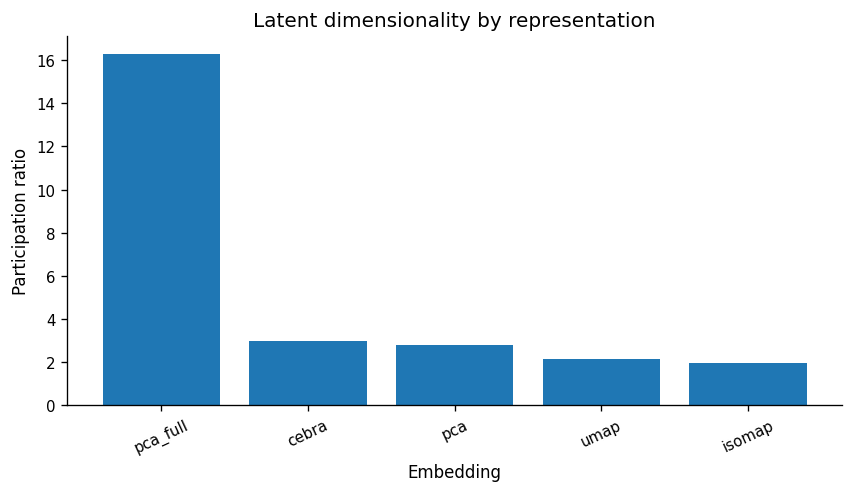

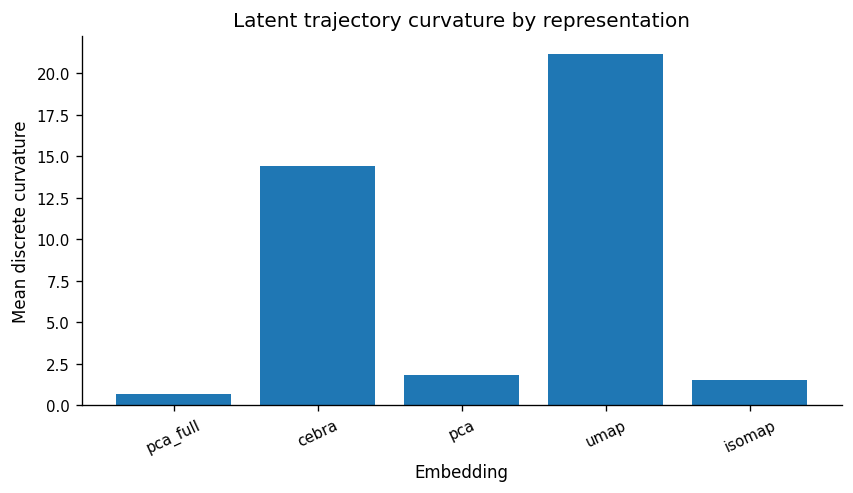

In [6]:
# ---------------------------------------------------------------------
# Geometry summary across embeddings
# ---------------------------------------------------------------------
geometry_summary = (
    geometry
    .sort_values("participation_ratio", ascending=False)
    .reset_index(drop=True)
)

save_table(
    geometry_summary,
    paths.tables_dir / "08_geometry_summary_by_embedding.csv",
)

display(geometry_summary)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(geometry_summary["embedding"], geometry_summary["participation_ratio"])
ax.set_xlabel("Embedding")
ax.set_ylabel("Participation ratio")
ax.set_title("Latent dimensionality by representation")
ax.tick_params(axis="x", rotation=25)

save_figure(
    fig,
    paths.figures_dir / "08_geometry_participation_ratio_by_embedding.png",
)

plt.show()


fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(geometry_summary["embedding"], geometry_summary["mean_discrete_curvature"])
ax.set_xlabel("Embedding")
ax.set_ylabel("Mean discrete curvature")
ax.set_title("Latent trajectory curvature by representation")
ax.tick_params(axis="x", rotation=25)

save_figure(
    fig,
    paths.figures_dir / "08_geometry_curvature_by_embedding.png",
)

plt.show()

### Best classification decoding results

,session_id,target,analysis,embedding,model,accuracy,balanced_accuracy,macro_f1,n_samples,n_features
2,500855614,dominant_orientation_confident_balanced_binary...,balanced_confident_frame_level_exploratory,pca_full,linear_svm,0.991379,0.991379,0.991379,116.0,20.0
1,500855614,dominant_orientation_coarse_secondary,frame_level_latent_exploratory,pca_full,linear_svm,0.958889,0.953914,0.940357,900.0,20.0
3,500855614,dominant_orientation_confident_exploratory,frame_level_latent_exploratory,umap,gradient_boosting,0.935556,0.904672,0.911012,900.0,3.0
0,500855614,dominant_orientation_bin_fine_exploratory,frame_level_latent_exploratory,pca_full,ridge_classifier,0.870000,0.820505,0.586829,900.0,20.0


c:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\src\v1_manifold\visualization.py:28: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.savefig(path, bbox_inches="tight")
c:\Users\Peter\.neuro\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


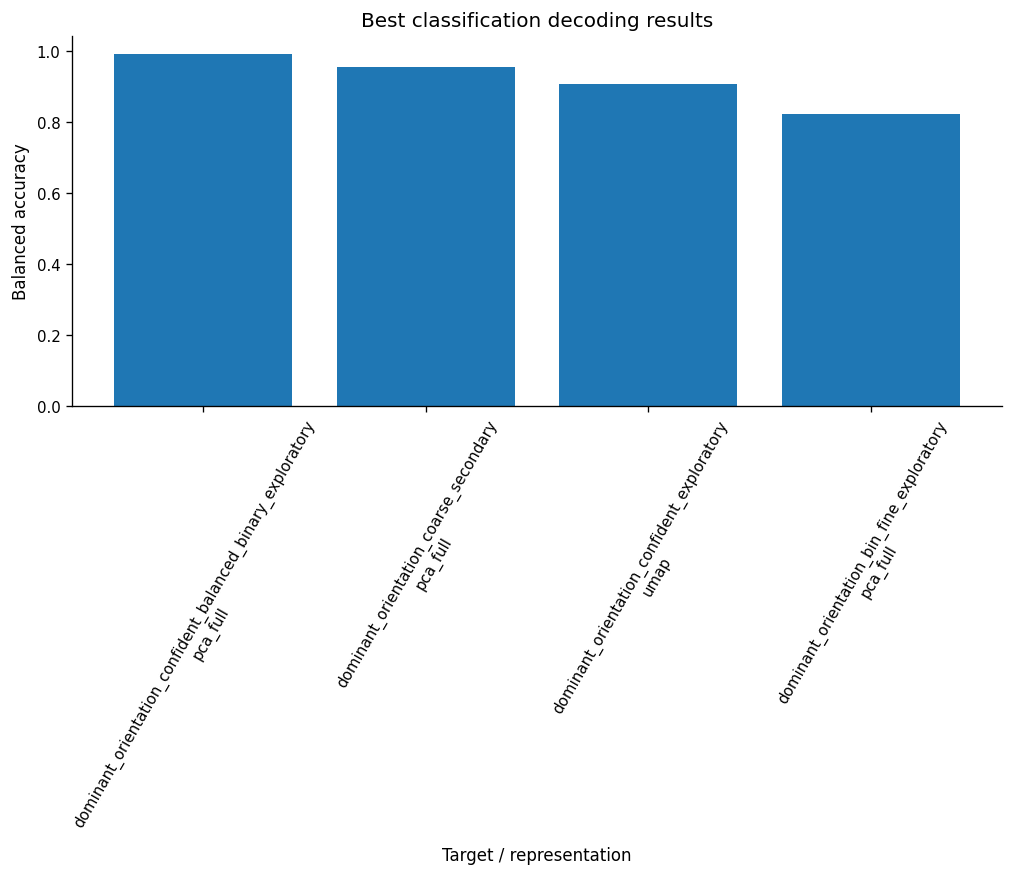

In [7]:
# ---------------------------------------------------------------------
# Best non-null classification decoders
# ---------------------------------------------------------------------
classification_results = integrated.dropna(subset=["balanced_accuracy"]).copy()

best_classification = (
    classification_results
    .sort_values("balanced_accuracy", ascending=False)
    .groupby(["target", "analysis"], as_index=False)
    .first()
    .sort_values("balanced_accuracy", ascending=False)
)

save_table(
    best_classification,
    paths.tables_dir / "08_best_classification_decoders.csv",
)

display(best_classification[
    [
        "session_id",
        "target",
        "analysis",
        "embedding",
        "model",
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "n_samples",
        "n_features",
    ]
].head(20))


plot_df = best_classification.head(12).copy()
plot_df["label"] = plot_df["target"] + "\n" + plot_df["embedding"].astype(str)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(plot_df["label"], plot_df["balanced_accuracy"])
ax.set_xlabel("Target / representation")
ax.set_ylabel("Balanced accuracy")
ax.set_title("Best classification decoding results")
ax.tick_params(axis="x", rotation=60)

save_figure(
    fig,
    paths.figures_dir / "08_best_classification_decoding_results.png",
)

plt.show()

### Continuous real-feature decoding summary

,target,session_id,analysis,embedding,model,mae,rmse,r2,n_samples,n_features
4,total_spectral_power,500855614,single_trial_repeat_heldout,raw_cells,random_forest_regressor,15455.182967,21177.296663,0.562762,9000,163
0,luminance_std,500855614,single_trial_repeat_heldout,raw_cells,random_forest_regressor,0.004443,0.006865,0.528322,9000,163
2,rms_contrast,500855614,single_trial_repeat_heldout,raw_cells,random_forest_regressor,0.008275,0.012827,0.522509,9000,163
1,orientation_selectivity,500855614,single_trial_repeat_heldout,raw_cells,random_forest_regressor,0.046945,0.064503,0.471925,9000,163
3,spatial_frequency_centroid,500855614,single_trial_repeat_heldout,raw_cells,random_forest_regressor,0.006456,0.008813,0.404585,9000,163


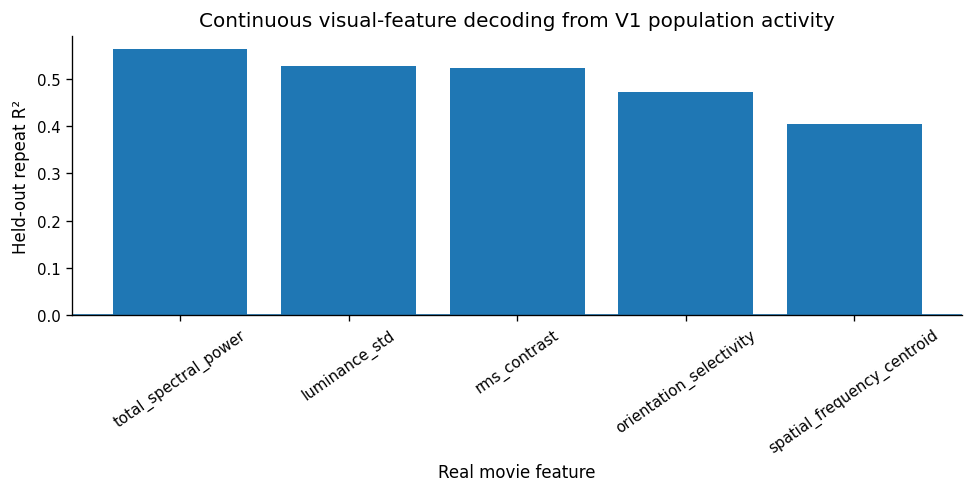

In [9]:
# ---------------------------------------------------------------------
# Continuous real movie-feature decoding summary
# ---------------------------------------------------------------------
if not regression.empty:
    regression_best = (
        regression
        .sort_values("r2", ascending=False)
        .groupby("target", as_index=False)
        .first()
        .sort_values("r2", ascending=False)
    )

    save_table(
        regression_best,
        paths.tables_dir / "08_best_continuous_feature_decoders.csv",
    )

    display(regression_best[
        [
            "target",
            "session_id",
            "analysis",
            "embedding",
            "model",
            "mae",
            "rmse",
            "r2",
            "n_samples",
            "n_features",
        ]
    ])

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(regression_best["target"], regression_best["r2"])
    ax.axhline(0, linewidth=1)
    ax.set_xlabel("Real movie feature")
    ax.set_ylabel("Held-out repeat R²")
    ax.set_title("Continuous visual-feature decoding from V1 population activity")
    ax.tick_params(axis="x", rotation=35)

    save_figure(
        fig,
        paths.figures_dir / "08_continuous_feature_decoding_r2.png",
    )

    plt.show()
else:
    print("No continuous regression table found.")

### CEBRA vs classical embeddings

,representation,mean_r2_across_targets,mean_spearman_across_targets,n_targets,source_file
0,umap,-9.277270,0.093386,5,07_cebra_representation_summary_session_500855...
1,pca,-11.514799,0.035455,5,07_cebra_representation_summary_session_500855...
2,isomap,-11.837900,0.007714,5,07_cebra_representation_summary_session_500855...
3,pca_full,-14.466427,0.102798,5,07_cebra_representation_summary_session_500855...
4,cebra,-15.678328,-0.013523,5,07_cebra_representation_summary_session_500855...


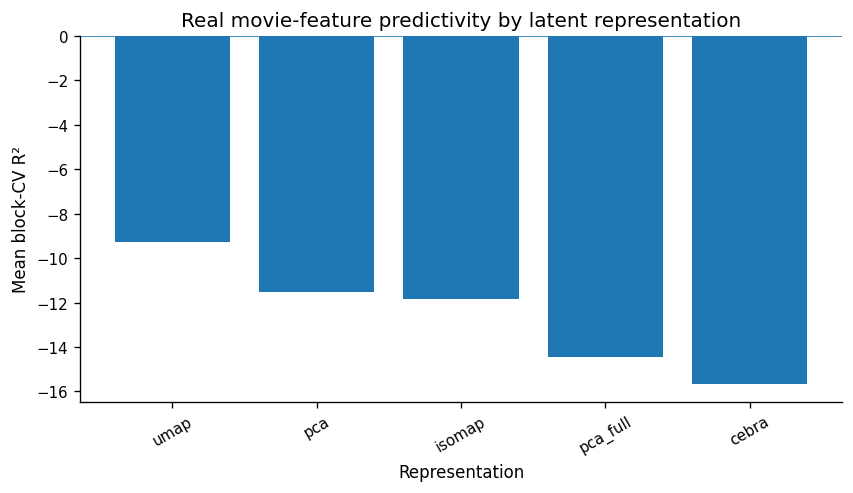

In [10]:
# ---------------------------------------------------------------------
# CEBRA versus classical latent embeddings
# ---------------------------------------------------------------------
if not cebra_summary.empty:
    cebra_summary_sorted = (
        cebra_summary
        .sort_values("mean_r2_across_targets", ascending=False)
        .reset_index(drop=True)
    )

    save_table(
        cebra_summary_sorted,
        paths.tables_dir / "08_cebra_vs_classical_embedding_summary.csv",
    )

    display(cebra_summary_sorted)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(
        cebra_summary_sorted["representation"],
        cebra_summary_sorted["mean_r2_across_targets"],
    )
    ax.axhline(0, linewidth=1)
    ax.set_xlabel("Representation")
    ax.set_ylabel("Mean block-CV R²")
    ax.set_title("Real movie-feature predictivity by latent representation")
    ax.tick_params(axis="x", rotation=30)

    save_figure(
        fig,
        paths.figures_dir / "08_cebra_vs_classical_embedding_summary.png",
    )

    plt.show()
else:
    print("No CEBRA comparison summary found.")

### dRNN baseline comparison

,model,n_samples,latent_dim,mse,rmse,mae,r2,source_file
0,persistence_baseline,870,3,0.015662,0.125146,0.082205,0.952929,07_drnn_next_state_baseline_comparison_session...
1,dRNN,870,3,0.015880,0.126015,0.085401,0.952273,07_drnn_next_state_baseline_comparison_session...
2,mean_state_baseline,870,3,0.333042,0.577098,0.501140,-0.000972,07_drnn_next_state_baseline_comparison_session...


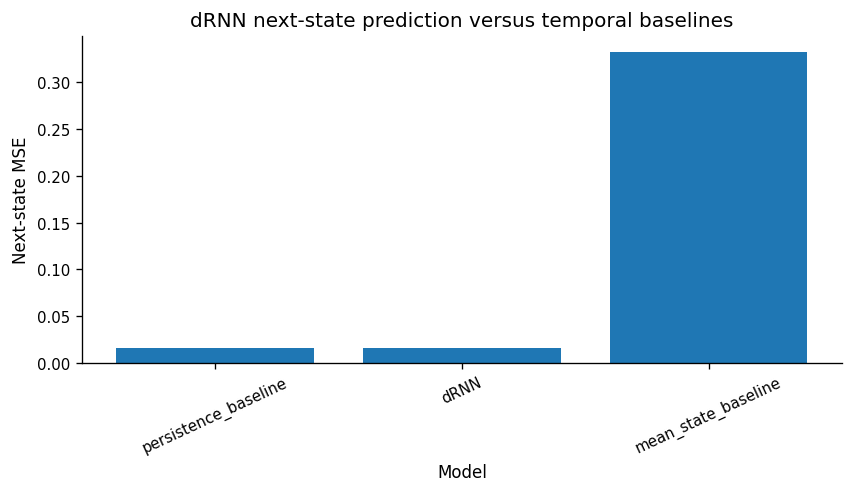

In [11]:
# ---------------------------------------------------------------------
# dRNN next-state prediction against temporal baselines
# ---------------------------------------------------------------------
if not drnn_baseline.empty:
    drnn_baseline_sorted = (
        drnn_baseline
        .sort_values("mse", ascending=True)
        .reset_index(drop=True)
    )

    save_table(
        drnn_baseline_sorted,
        paths.tables_dir / "08_drnn_baseline_comparison_summary.csv",
    )

    display(drnn_baseline_sorted)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(drnn_baseline_sorted["model"], drnn_baseline_sorted["mse"])
    ax.set_xlabel("Model")
    ax.set_ylabel("Next-state MSE")
    ax.set_title("dRNN next-state prediction versus temporal baselines")
    ax.tick_params(axis="x", rotation=25)

    save_figure(
        fig,
        paths.figures_dir / "08_drnn_next_state_baseline_comparison.png",
    )

    plt.show()
else:
    print("No dRNN baseline table found.")

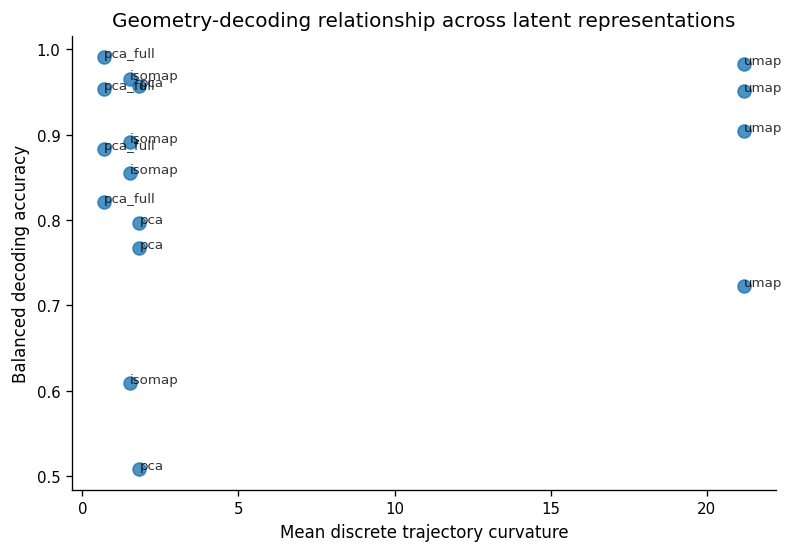

In [12]:
# ---------------------------------------------------------------------
# Geometry-decoding relationship using available reconstructed geometry metrics
# ---------------------------------------------------------------------
plot_df = integrated.dropna(
    subset=["mean_discrete_curvature", "balanced_accuracy"]
).copy()

# I keep only non-null models if the column exists.
if "is_null_baseline" in plot_df.columns:
    plot_df = plot_df[
        ~plot_df["is_null_baseline"].astype(str).str.lower().isin(["true", "1", "yes"])
    ].copy()

if len(plot_df):
    fig, ax = plt.subplots(figsize=(6.5, 4.5))

    ax.scatter(
        plot_df["mean_discrete_curvature"],
        plot_df["balanced_accuracy"],
        s=60,
        alpha=0.8,
    )

    for _, row in plot_df.iterrows():
        label = f"{row['embedding']}"
        ax.text(
            row["mean_discrete_curvature"],
            row["balanced_accuracy"],
            label,
            fontsize=8,
            alpha=0.8,
        )

    ax.set_xlabel("Mean discrete trajectory curvature")
    ax.set_ylabel("Balanced decoding accuracy")
    ax.set_title("Geometry-decoding relationship across latent representations")

    save_figure(
        fig,
        paths.figures_dir / "08_curvature_vs_decoding_accuracy.png",
    )

    plt.show()
else:
    print("No rows available for curvature-decoding plotting.")

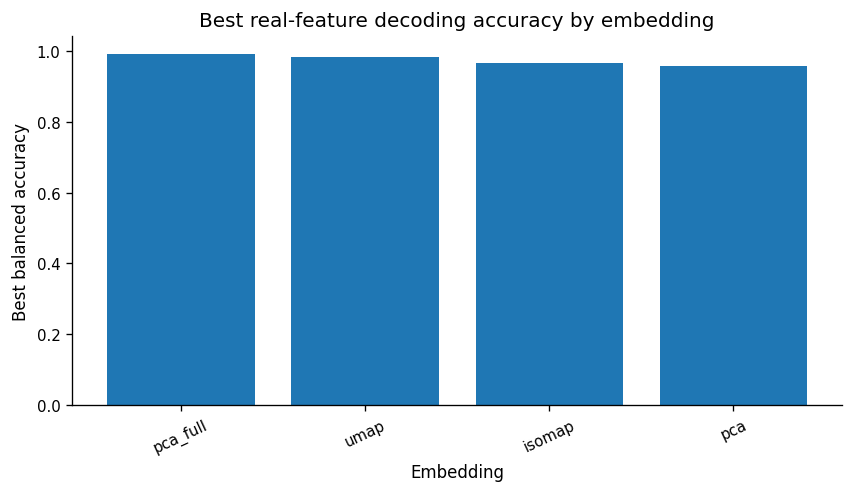

In [13]:
# ---------------------------------------------------------------------
# Best non-null decoding accuracy by embedding
# ---------------------------------------------------------------------
plot_df = integrated.dropna(subset=["balanced_accuracy"]).copy()

if "is_null_baseline" in plot_df.columns:
    plot_df = plot_df[
        ~plot_df["is_null_baseline"].astype(str).str.lower().isin(["true", "1", "yes"])
    ].copy()

best_by_embedding = (
    plot_df
    .sort_values("balanced_accuracy", ascending=False)
    .groupby("embedding", as_index=False)
    .first()
    .sort_values("balanced_accuracy", ascending=False)
)

save_table(
    best_by_embedding,
    paths.tables_dir / "08_best_decoding_accuracy_by_embedding.csv",
)

if len(best_by_embedding):
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.bar(
        best_by_embedding["embedding"],
        best_by_embedding["balanced_accuracy"],
    )

    ax.set_xlabel("Embedding")
    ax.set_ylabel("Best balanced accuracy")
    ax.set_title("Best real-feature decoding accuracy by embedding")
    ax.tick_params(axis="x", rotation=25)

    save_figure(
        fig,
        paths.figures_dir / "08_best_real_feature_decoding_by_embedding.png",
    )

    plt.show()
else:
    print("No decoding rows available for plotting.")